# First tests on the highway-env environment

In [1]:
import gymnasium as gym
from collections import deque
import highway_env
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
from tqdm import tqdm
from stable_baselines3 import DQN as SB3_DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from shared_core_config import SHARED_CORE_ENV_ID, SHARED_CORE_CONFIG

c:\Users\maesf\anaconda3\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


### First environment

In [2]:
def make_env(render_mode="rgb_array"):
    env = gym.make("highway-v0", render_mode=render_mode)
    env.unwrapped.configure(SHARED_CORE_CONFIG)
    env.reset()
    env = Monitor(env) 
    return env

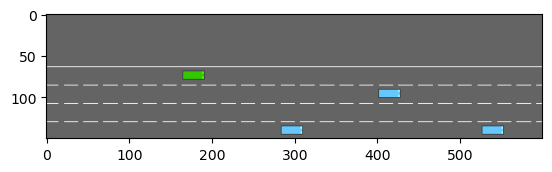

Observation space shape: (10, 5)
Action space: Discrete(5)


In [17]:
temp_env = make_env()
obs, info = temp_env.reset()

# Visualization
plt.imshow(temp_env.render())
plt.show()
print(f"Observation space shape: {temp_env.observation_space.shape}")
print(f"Action space: {temp_env.action_space}")

### Test with random actions

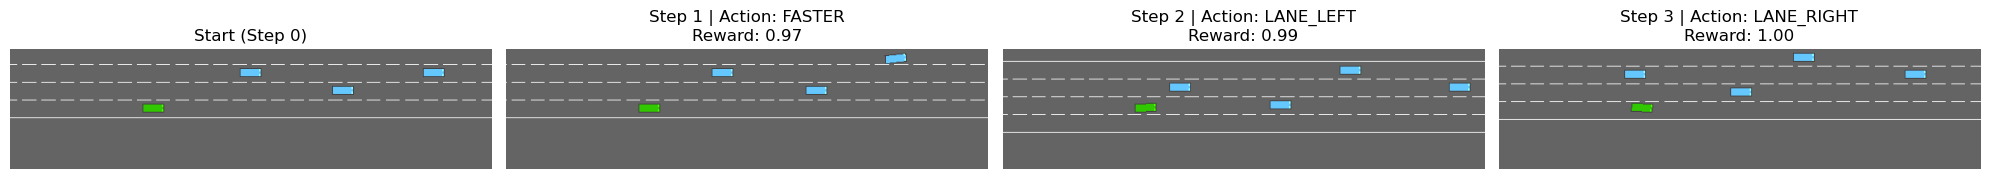

In [20]:
env = make_env(render_mode="rgb_array")

obs, info = env.reset()

# Plotting the start, and the result of 3 actions
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot the starting state
axes[0].imshow(env.render())
axes[0].set_title("Start (Step 0)")
axes[0].axis('off')

action_names = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}

for step in range(1, 4):
    # We pick a random action
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    # Plot
    axes[step].imshow(env.render())
    title = f"Step {step} | Action: {action_names[action]}\nReward: {reward:.2f}"
    axes[step].set_title(title)
    axes[step].axis('off')
    if terminated or truncated:
        print(f"Episode ended early at step {step}!")
        break
plt.tight_layout()
plt.show()

env.close()

### Define a function to evaluate models

In [5]:
def evaluate_agent(model, num_episodes=50, seeds=[3, 33, 333]):
    """Evaluates the agent over multiple seeds and episodes"""
    print(f"Starting evaluation: {num_episodes} episodes per seed.")
    all_seed_results = []
    
    for seed in seeds:

        env = make_env()
        episode_rewards = []
        for episode in tqdm(range(num_episodes), desc=f"Current seed: {seed}"):
            obs, info = env.reset(seed=seed + episode)
            done = False
            total_reward = 0
            while not done:
                # For a given state, our model precits the action we will do
                action, _states = model.predict(obs, deterministic=True)
                # Now we take the action given by our model
                obs, reward, terminated, truncated, info = env.step(action)
                total_reward += reward
                done = terminated or truncated
            # Now that the episode is finished, we can add the total reward to our list
            episode_rewards.append(total_reward)    
        env.close()
        
        # Now that we have ran it for all episodes, we can compute the mean adn standard deviation
        # of the total rewards
        mean_reward = np.mean(episode_rewards)
        std_reward = np.std(episode_rewards)
        print(f"Seed {seed} | Mean reward: {mean_reward:.2f} | Std: {std_reward:.2f}")
        all_seed_results.append((seed, mean_reward, std_reward))
        
    return all_seed_results

### Train the Stable-Baselines3 baseline model

In [6]:
# env_sb3 = make_env()

# print("Initializing SB3 DQN")

#    model_sb3 = SB3_DQN(
#       policy="MlpPolicy", 
#        env=env_sb3, 
#        learning_rate=5e-4,
#        buffer_size=15000,
#        learning_starts=200,
#        batch_size=32,
#        gamma=0.8,
#        train_freq=1,
#        gradient_steps=1,
#        target_update_interval=50,
#        exploration_fraction=0.7,
#        verbose=1 
#    )

# print("Starting training")

# model_sb3.learn(total_timesteps=20000)
# model_sb3.save("dqn_sb3_highway")

# print("SB3 Baseline training complete and model saved")

### Evaluate the SB3 Baseline model

In [7]:
from stable_baselines3 import DQN as SB3_DQN

model_sb3 = SB3_DQN.load("dqn_sb3_highway")

sb3_results = evaluate_agent(model_sb3, num_episodes=50)

Starting evaluation: 50 episodes per seed.


Current seed: 3: 100%|██████████| 50/50 [05:16<00:00,  6.32s/it]


Seed 3 | Mean reward: 10.57 | Std: 5.77


Current seed: 33: 100%|██████████| 50/50 [05:44<00:00,  6.89s/it]


Seed 33 | Mean reward: 11.64 | Std: 6.20


Current seed: 333: 100%|██████████| 50/50 [05:07<00:00,  6.15s/it]

Seed 333 | Mean reward: 9.90 | Std: 4.88


### Implement a DQN

#### 1 - Replay Buffer

In [8]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = [] # stores the transitions
        self.position = 0 # tells us where to insert the next transition

    def push(self, state, action, reward, terminated, next_state):
        """Saves a transition"""
        if len(self.memory) < self.capacity:
            self.memory.append(None)  
        # Her we overwrite the oldest memory (transition) with the new one
        self.memory[self.position] = (state, action, reward, terminated, next_state)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        """Pick a random batch of transitions, that will be used to train the model"""
        return random.sample(self.memory, k=batch_size)

    def __len__(self):
        return len(self.memory)

#### 2 - Neural Network

In [9]:
class Net(nn.Module):
    def __init__(self, obs_shape, hidden_size, n_actions):
        super(Net, self).__init__()
        # As we have 10 cars and 5 features per car, we use 50 input neurons
        flattened_size = obs_shape[0] * obs_shape[1] 
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions) # returns the 5 Q values (one for each action)
        )
    def forward(self, x):
        return self.net(x)

### 3 - Agent

In [ ]:
class CustomDQNAgent:
    def __init__(self, action_space, observation_space):
        self.action_space = action_space
        self.observation_space = observation_space
        # Hyperparameters
        self.learning_rate = 5e-4
        self.gamma = 0.8 # Discount factor
        self.batch_size = 32
        self.buffer_capacity = 15000 # Memory size
        self.update_target_every = 50
        # Exploration parameters
        self.epsilon_start = 0.9 # Start here because it will change: we will decrease it
        self.epsilon_min = 0.05
        self.decrease_epsilon_factor = 2000
        self.epsilon = self.epsilon_start
        
        # Initializiation
        self.buffer = ReplayBuffer(self.buffer_capacity)
        obs_shape = self.observation_space.shape
        n_actions = self.action_space.n
        hidden_size = 128 
        
        # Define the Deep Q-network and the target network
        self.q_net = Net(obs_shape, hidden_size, n_actions)
        self.target_net = Net(obs_shape, hidden_size, n_actions)
        # We ensure that they have the same weight at the beginning
        self.target_net.load_state_dict(self.q_net.state_dict()) 
        
        self.optimizer = optim.Adam(params=self.q_net.parameters(), lr=self.learning_rate)
        self.loss_function = nn.MSELoss()
        
        self.n_steps = 0 # Total steps
        self.n_eps = 0 # Total episodes

    def get_q(self, state):
        """Get the Q values of the given state by using the network"""
        # Convert numpy state to PyTorch tensor
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            output = self.q_net.forward(state_tensor)
        return output.numpy()[0]
    
    def get_action(self, state):
        """Chooses an action using the epsilon-greedyfication"""
        if np.random.rand() < self.epsilon:
            return self.action_space.sample()
        else:
            q_values = self.get_q(state)
            return np.argmax(q_values)
            
    def decrease_epsilon(self):
        """Gradually reduces the chance of taking random actions over time"""
        self.epsilon = self.epsilon_min + (self.epsilon_start - self.epsilon_min) * (
                        np.exp(-1. * self.n_eps / self.decrease_epsilon_factor) )
        
    def update(self, state, action, reward, terminated, next_state):
        """Stores the transition and performs one step of gradient descent"""
        
        # Store the transition in the Replay Buffer
        # Convert the inputs to tensors
        self.buffer.push(
            torch.tensor(state, dtype=torch.float32).unsqueeze(0), 
            torch.tensor([[action]], dtype=torch.int64), 
            torch.tensor([reward], dtype=torch.float32), 
            torch.tensor([terminated], dtype=torch.int64), 
            torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
        )
        # Check that we have enough data to train
        if len(self.buffer) < self.batch_size:
            return np.inf 

        # Dample a batch
        transitions = self.buffer.sample(self.batch_size)

        # Transpose the batch
        state_batch, action_batch, reward_batch, terminated_batch, next_state_batch = tuple(
            [torch.cat(data) for data in zip(*transitions)]
        )

        # Compute current Q-values
        q_values = self.q_net(state_batch).gather(1, action_batch)

        # Compute target Q-values (Bellman equation)
        with torch.no_grad():
            # Get the max Q-value for the next states from the target network
            next_state_values = self.target_net(next_state_batch).max(1)[0]
            # If the state was terminal, there is no future reward, so we multiply by (1 - terminated_batch)
            next_state_values = next_state_values * (1 - terminated_batch)
            # Compute the expected Q values
            targets = reward_batch + (self.gamma * next_state_values)

        # Compute loss and backpropagate
        loss = self.loss_function(q_values, targets.unsqueeze(1))
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update target network if necessary
        if self.n_steps % self.update_target_every == 0: 
            self.target_net.load_state_dict(self.q_net.state_dict())
        
        # Update epsilon
        self.decrease_epsilon()
        self.n_steps += 1
        if terminated: 
            self.n_eps += 1
        return loss.item()

#### 4 - Train the DQN model

In [11]:
env_custom = make_env()
agent = CustomDQNAgent(env_custom.action_space, env_custom.observation_space)

N_EPISODES = 500  # 500 episodes is equivalent to the 15k-20k timesteps used in SB3
episode_rewards = []
episode_losses = []

for ep in tqdm(range(N_EPISODES), desc="Training Custom DQN"):
    state, _ = env_custom.reset()
    done = False
    total_reward = 0
    ep_losses = []
    
    while not done:
        action = agent.get_action(state)
        next_state, reward, terminated, truncated, _ = env_custom.step(action)
        done = terminated or truncated

        loss = agent.update(state, action, reward, terminated, next_state)
        
        state = next_state
        total_reward += reward
        
        if loss != np.inf:
            ep_losses.append(loss)
            
    # Now that the episode is finished, we save its total rewards
    episode_rewards.append(total_reward)
    if ep_losses:
        episode_losses.append(np.mean(ep_losses))

env_custom.close()

Training Custom DQN: 100%|██████████| 500/500 [1:21:30<00:00,  9.78s/it]


Save model

In [12]:
file_path = "custom_dqn_highway.pth"
torch.save(agent.q_net.state_dict(), file_path)

#### 5 - Plot the training curves

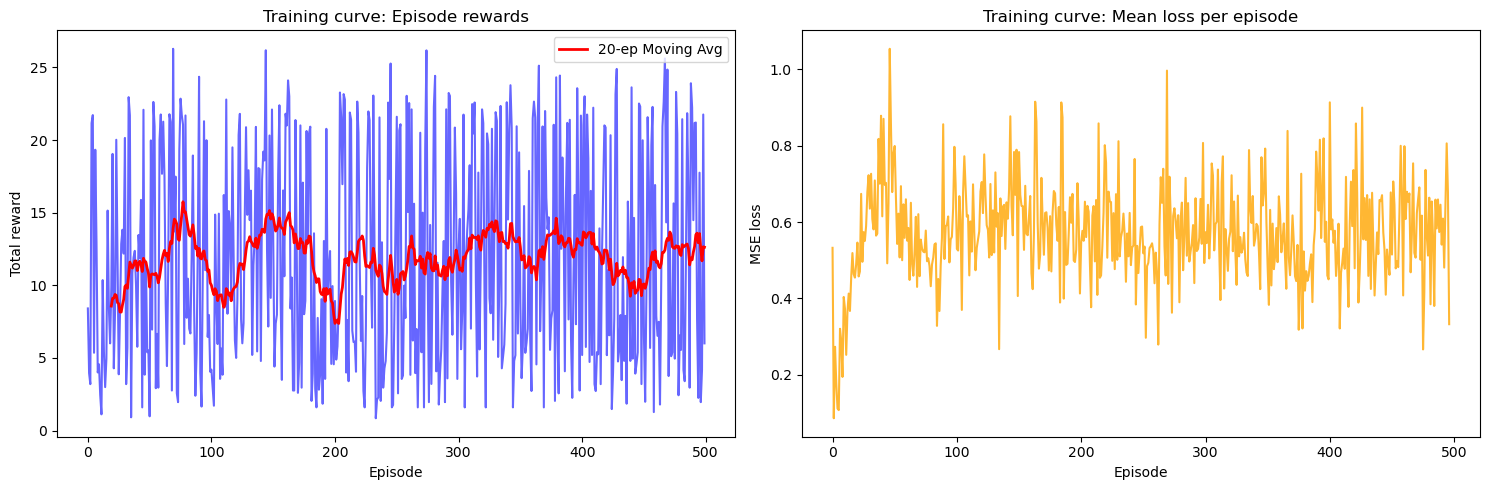

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Reward curve
axes[0].plot(episode_rewards, alpha=0.6, color='blue')
if len(episode_rewards) >= 20:
    rolling_avg = np.convolve(episode_rewards, np.ones(20)/20, mode='valid')
    axes[0].plot(range(19, len(episode_rewards)), rolling_avg, color='red', linewidth=2, label='20-ep Moving Avg')
axes[0].set_title("Training curve: Episode rewards")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].legend()

# Loss curve
axes[1].plot(episode_losses, color='orange', alpha=0.8)
axes[1].set_title("Training curve: Mean loss per episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("MSE loss")

plt.tight_layout()
plt.show()

### Evaluate the DQN model

In [14]:
def evaluate_custom_agent(agent, num_episodes=50, seeds=[3, 33, 333]):
    """Evaluates the custom agent deterministically over multiple seeds"""
    print(f"Starting evaluation: {num_episodes} episodes per seed.")
    all_seed_results = []
    
    for seed in seeds:
        env = make_env()
        episode_rewards = []
        
        for episode in tqdm(range(num_episodes), desc=f"Evaluating Seed {seed}"):
            obs, info = env.reset(seed=seed + episode)
            done = False
            total_reward = 0
            while not done:
                q_values = agent.get_q(obs)
                action = np.argmax(q_values) # action with greatest Q-value
                obs, reward, terminated, truncated, info = env.step(action)
                total_reward += reward
                done = terminated or truncated
            episode_rewards.append(total_reward)
            
        env.close()
        
        # Now that we have all the rewards, we can compute the mean and std for this seed
        mean_reward = np.mean(episode_rewards)
        std_reward = np.std(episode_rewards)
        print(f"Seed {seed} | Mean Reward: {mean_reward:.2f} | Std: {std_reward:.2f}\n")
        all_seed_results.append((seed, mean_reward, std_reward))
        
    return all_seed_results

In [15]:
custom_results = evaluate_custom_agent(agent, num_episodes=50)

Starting evaluation: 50 episodes per seed.


Evaluating Seed 3: 100%|██████████| 50/50 [09:47<00:00, 11.75s/it]


Seed 3 | Mean Reward: 16.12 | Std: 6.85



Evaluating Seed 33: 100%|██████████| 50/50 [10:11<00:00, 12.24s/it]


Seed 33 | Mean Reward: 16.92 | Std: 6.49



Evaluating Seed 333: 100%|██████████| 50/50 [09:48<00:00, 11.77s/it]

Seed 333 | Mean Reward: 15.50 | Std: 7.16



#### Record a rollout

Recording rollout
Episode finished after 30 steps.


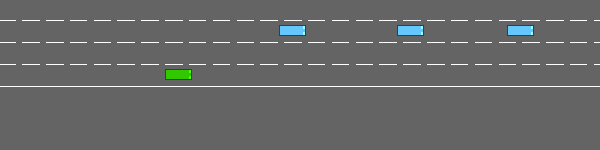

In [23]:
import imageio
from IPython.display import Image

env_record = make_env(render_mode="rgb_array")

seed_to_record = 33
obs, info = env_record.reset(seed=seed_to_record)

frames = []
done = False
step_count = 0

print(f"Recording rollout")

while not done:
    # Capture the visual frame
    frame = env_record.render()
    frames.append(frame)
    q_values = agent.get_q(obs)
    action = np.argmax(q_values)
    # Take the action
    obs, reward, terminated, truncated, info = env_record.step(action)
    done = terminated or truncated
    step_count += 1

env_record.close()

# Save the frames as a GIF
gif_path = f"custom_dqn_rollout_seed{seed_to_record}.gif"
imageio.mimsave(gif_path, frames, fps=15)

print(f"Episode finished after {step_count} steps.")

# Display the GIF
Image(open(gif_path, 'rb').read())